# 05 · Causal masking — no peeking at the future

To *generate* text left-to-right, token *i* may only attend to itself and tokens **before** it
— never after (they aren't written yet). We enforce this with a **causal mask**: hide the
upper triangle of the attention matrix. This is exactly what makes GPT-style models
**decoder-only**.

In [1]:
import numpy as np
np.random.seed(0)
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)
def attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None: scores = np.where(mask, scores, -1e9)
    w = softmax(scores, axis=-1); return w @ V, w

T, d = 5, 8
X = np.random.randn(T, d)
Wq, Wk, Wv = (np.random.randn(d, d) for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv

causal = np.tril(np.ones((T, T))).astype(bool)   # lower triangle True = allowed (self + past)
print("causal mask (True = may attend):\n", causal)

_, w_full   = attention(Q, K, V)
_, w_masked = attention(Q, K, V, mask=causal)
assert (np.triu(w_masked, k=1) == 0).all()       # zero weight on any future token

causal mask (True = may attend):
 [[ True False False False False]
 [ True  True False False False]
 [ True  True  True False False]
 [ True  True  True  True False]
 [ True  True  True  True  True]]


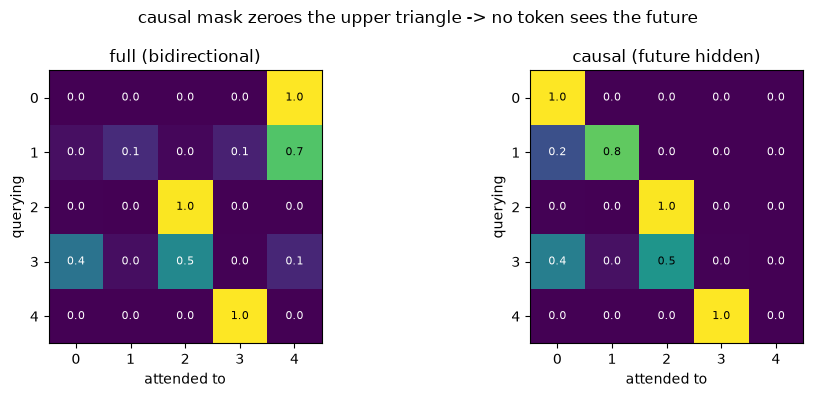

In [2]:
# Visual: full attention vs causal-masked attention.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, W, title in [(axes[0], w_full, "full (bidirectional)"),
                     (axes[1], w_masked, "causal (future hidden)")]:
    im = ax.imshow(W, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("attended to"); ax.set_ylabel("querying")
    for i in range(len(W)):
        for j in range(len(W)):
            ax.text(j, i, f"{W[i,j]:.1f}", ha="center", va="center",
                    color="white" if W[i,j] < 0.5 else "black", fontsize=8)
fig.suptitle("causal mask zeroes the upper triangle -> no token sees the future")
plt.tight_layout(); plt.show()

**Takeaway.** The causal mask is one triangular matrix, but it's the whole reason a decoder
can generate: token *t* is predicted using only tokens `1..t`. Next: **06 · multi-head
attention**.